# Created by:
#### Satvik Kesarwani 2502140110


# Online Retail Data Analysis

## Problem Statement
The goal of this project is to analyze an online retail dataset to understand 
customer behavior, product preferences, payment trends, and sales performance 
over time. The insights will help the business make data-driven decisions to 
improve revenue and customer satisfaction.

## Dataset Description
- **Dataset:** Synthetic Online Retail Data  
- **Rows:** 1000+ records  
- **Columns:** 'customer_id', 'order_date', 'product_id', 'category_id',
               'category_name', 'product_name', 'quantity', 'price', 'payment_method',
               'city', 'review_score', 'gender', 'age'
 
- **Source:** Kaggle "https://www.kaggle.com/datasets/ertugrulesol/online-retail-data"

In [84]:
import pandas as pd
import numpy as np

In [85]:
df = pd.read_csv("synthetic_online_retail_data.csv")

# Data Loading & Understanding:

In [86]:
df.head()  # this will print starting few rows of the csv

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.0,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,NaN,M,59
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.0,F,64
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.0,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.0,F,33


In [87]:
df.shape

(1000, 13)

In [88]:
df.columns # this will list all the columns in the csv

Index(['customer_id', 'order_date', 'product_id', 'category_id',
       'category_name', 'product_name', 'quantity', 'price', 'payment_method',
       'city', 'review_score', 'gender', 'age'],
      dtype='object')

In [89]:
df.info() # this will print the whole table

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     1000 non-null   int64  
 1   order_date      1000 non-null   object 
 2   product_id      1000 non-null   int64  
 3   category_id     1000 non-null   int64  
 4   category_name   1000 non-null   object 
 5   product_name    1000 non-null   object 
 6   quantity        1000 non-null   int64  
 7   price           1000 non-null   float64
 8   payment_method  1000 non-null   object 
 9   city            1000 non-null   object 
 10  review_score    799 non-null    float64
 11  gender          897 non-null    object 
 12  age             1000 non-null   int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB


In [90]:
df.dtypes # this will tell the datatype of eaxh columns

customer_id         int64
order_date         object
product_id          int64
category_id         int64
category_name      object
product_name       object
quantity            int64
price             float64
payment_method     object
city               object
review_score      float64
gender             object
age                 int64
dtype: object

# Data Cleaning & Wrangling:

In [91]:
df.isnull().sum()  # this will help in checking for the missing values 

customer_id         0
order_date          0
product_id          0
category_id         0
category_name       0
product_name        0
quantity            0
price               0
payment_method      0
city                0
review_score      201
gender            103
age                 0
dtype: int64

In [92]:
df['review_score'] = df['review_score'].fillna(df['review_score'].mean())   # this will replace all the missing 
df['review_score']                                                          # values in review_score with the mean of review_score

0      1.000000
1      3.992491
2      5.000000
3      5.000000
4      1.000000
         ...   
995    3.992491
996    3.000000
997    3.992491
998    3.000000
999    1.000000
Name: review_score, Length: 1000, dtype: float64

In [93]:
df['gender'] = df['gender'].fillna('Unknown')  # this will replace all the missing values in gender with unknown
df['gender'] 

0            F
1            M
2            F
3            M
4            F
        ...   
995    Unknown
996          F
997          M
998          M
999          M
Name: gender, Length: 1000, dtype: object

In [94]:
df = df.drop_duplicates()    # this will remove all the rows with duplicate values
df

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.000000,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,3.992491,M,59
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.000000,F,64
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.000000,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.000000,F,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,67967,2024-05-04,965,40,Books & Stationery,Notebook,3,495.24,Cash on Delivery,Hodgemouth,3.992491,Unknown,30
996,99828,2024-09-12,510,40,Books & Stationery,Story Book,5,427.73,Credit Card,Douglastown,3.000000,F,72
997,92290,2024-11-06,445,10,Electronics,Smartphone,5,354.64,Bank Transfer,New Amberville,3.992491,M,49
998,61427,2024-09-17,410,10,Electronics,Laptop,4,221.54,Cash on Delivery,New Sean,3.000000,M,71


In [95]:
df['order_date'] = pd.to_datetime(df['order_date'])    # this will change the datatype to datetime64 
df['order_date']

0     2024-12-17
1     2024-06-01
2     2025-02-04
3     2024-10-28
4     2024-05-10
         ...    
995   2024-05-04
996   2024-09-12
997   2024-11-06
998   2024-09-17
999   2024-11-06
Name: order_date, Length: 1000, dtype: datetime64[ns]

In [96]:
df.dtypes

customer_id                int64
order_date        datetime64[ns]
product_id                 int64
category_id                int64
category_name             object
product_name              object
quantity                   int64
price                    float64
payment_method            object
city                      object
review_score             float64
gender                    object
age                        int64
dtype: object

In [97]:
df_filtered = df[df['price'] > 50]
df_filtered

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.000000,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,3.992491,M,59
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.000000,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.000000,F,33
5,29989,2024-12-03,829,10,Electronics,Smartphone,4,196.16,Bank Transfer,East Tonyaberg,5.000000,F,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,67967,2024-05-04,965,40,Books & Stationery,Notebook,3,495.24,Cash on Delivery,Hodgemouth,3.992491,Unknown,30
996,99828,2024-09-12,510,40,Books & Stationery,Story Book,5,427.73,Credit Card,Douglastown,3.000000,F,72
997,92290,2024-11-06,445,10,Electronics,Smartphone,5,354.64,Bank Transfer,New Amberville,3.992491,M,49
998,61427,2024-09-17,410,10,Electronics,Laptop,4,221.54,Cash on Delivery,New Sean,3.000000,M,71


In [98]:
df_filtered = df[df['gender'] == 'M']
df_filtered

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,3.992491,M,59
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.000000,M,34
6,79809,2024-06-07,706,10,Electronics,Tablet,5,272.75,Bank Transfer,North Jessicabury,3.992491,M,57
10,27389,2025-01-31,549,10,Electronics,Smartwatch,2,321.14,Cash on Delivery,Elizabethmouth,5.000000,M,26
11,74067,2024-06-27,773,40,Books & Stationery,Notebook,3,494.87,Cash on Delivery,Melanieberg,5.000000,M,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,43591,2024-06-12,302,50,Sports & Outdoors,Running Shoes,4,170.43,Cash on Delivery,Frankbury,5.000000,M,37
993,94141,2024-09-01,701,20,Fashion,Skirt,4,270.32,Bank Transfer,North Jeannemouth,5.000000,M,48
997,92290,2024-11-06,445,10,Electronics,Smartphone,5,354.64,Bank Transfer,New Amberville,3.992491,M,49
998,61427,2024-09-17,410,10,Electronics,Laptop,4,221.54,Cash on Delivery,New Sean,3.000000,M,71


In [99]:
df_filtered = df[(df['price'] > 100) | (df['quantity'] > 2)]   # here two conditions have been appilied wich will filter out rows 
                                                               # greater than 100 and quantity greater than 2
df_filtered

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.000000,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,3.992491,M,59
2,55098,2025-02-04,684,50,Sports & Outdoors,Tent,5,23.00,Credit Card,West Sarah,5.000000,F,64
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.000000,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.000000,F,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,67967,2024-05-04,965,40,Books & Stationery,Notebook,3,495.24,Cash on Delivery,Hodgemouth,3.992491,Unknown,30
996,99828,2024-09-12,510,40,Books & Stationery,Story Book,5,427.73,Credit Card,Douglastown,3.000000,F,72
997,92290,2024-11-06,445,10,Electronics,Smartphone,5,354.64,Bank Transfer,New Amberville,3.992491,M,49
998,61427,2024-09-17,410,10,Electronics,Laptop,4,221.54,Cash on Delivery,New Sean,3.000000,M,71


In [100]:
df_filtered = df[df['price'].between(100, 500)]  #this will filter all the rows which has betwen 100-500
df_filtered

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
0,13542,2024-12-17,784,10,Electronics,Smartphone,2,373.36,Credit Card,New Oliviaberg,1.000000,F,56
1,23188,2024-06-01,682,50,Sports & Outdoors,Soccer Ball,5,299.34,Credit Card,Port Matthew,3.992491,M,59
3,65208,2024-10-28,204,40,Books & Stationery,Story Book,2,230.11,Bank Transfer,Hernandezburgh,5.000000,M,34
4,63872,2024-05-10,202,20,Fashion,Skirt,4,176.72,Credit Card,Jenkinshaven,1.000000,F,33
5,29989,2024-12-03,829,10,Electronics,Smartphone,4,196.16,Bank Transfer,East Tonyaberg,5.000000,F,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,67967,2024-05-04,965,40,Books & Stationery,Notebook,3,495.24,Cash on Delivery,Hodgemouth,3.992491,Unknown,30
996,99828,2024-09-12,510,40,Books & Stationery,Story Book,5,427.73,Credit Card,Douglastown,3.000000,F,72
997,92290,2024-11-06,445,10,Electronics,Smartphone,5,354.64,Bank Transfer,New Amberville,3.992491,M,49
998,61427,2024-09-17,410,10,Electronics,Laptop,4,221.54,Cash on Delivery,New Sean,3.000000,M,71


In [101]:
df = df.sort_values(by='price', ascending=False)    # this will sort the values in descending order
df

,customer_id,order_date,product_id,category_id,category_name,product_name,quantity,price,payment_method,city,review_score,gender,age
950,21063,2025-01-23,327,20,Fashion,Shirt,2,499.50,Bank Transfer,Dorseymouth,3.992491,M,66
866,82894,2024-12-15,585,20,Fashion,Shirt,1,499.23,Bank Transfer,Johnstad,5.000000,Unknown,58
434,23420,2024-08-19,508,20,Fashion,Shirt,4,498.66,Credit Card,Port Adrianhaven,5.000000,F,56
774,39427,2024-06-13,292,20,Fashion,T-shirt,3,498.44,Bank Transfer,Connerstad,3.000000,M,60
700,92859,2024-09-12,727,50,Sports & Outdoors,Running Shoes,3,498.35,Cash on Delivery,Patriciaville,3.992491,F,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,63919,2024-04-23,209,40,Books & Stationery,Pen,3,12.89,Bank Transfer,Jeffreyville,2.000000,M,54
716,43139,2024-07-06,669,10,Electronics,Smartphone,5,12.46,Cash on Delivery,Veronicaland,3.000000,F,67
54,57158,2024-07-25,294,30,Home & Living,Pillow,4,11.74,Credit Card,Woodshaven,5.000000,M,59
934,57116,2024-10-06,319,20,Fashion,Pants,5,11.73,Bank Transfer,Catherinestad,3.992491,F,60


In [102]:
df['total_amount'] = df['quantity'] * df['price']
df['total_amount']

950     999.00
866     499.23
434    1994.64
774    1495.32
700    1495.05
        ...   
89       38.67
716      62.30
54       46.96
934      58.65
520      21.44
Name: total_amount, Length: 1000, dtype: float64

# Data Visualization:

In [103]:
import matplotlib.pyplot as plt

In [104]:
print(df.columns)

Index(['customer_id', 'order_date', 'product_id', 'category_id',
       'category_name', 'product_name', 'quantity', 'price', 'payment_method',
       'city', 'review_score', 'gender', 'age', 'total_amount'],
      dtype='object')


## Category count (Bar Graph)

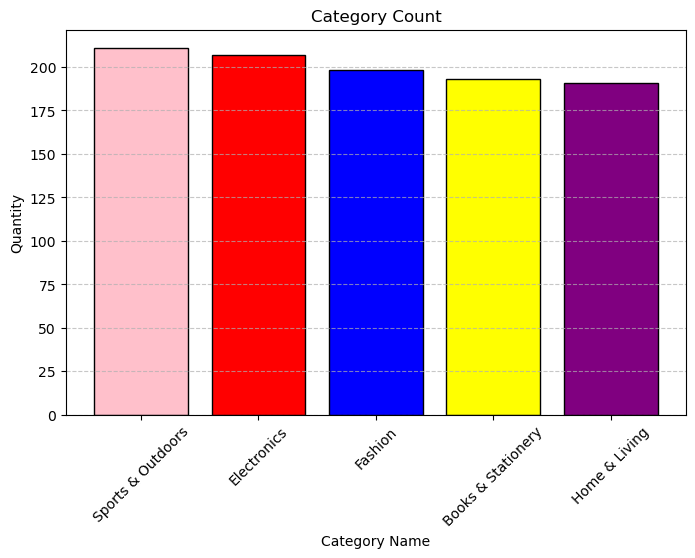

In [105]:
# bar graph
plt.figure(figsize=(8,5))     # this will fix the dimension of the graph 
plt.bar(df['category_name'].value_counts().index,  # Index represents the labels of the data
        df['category_name'].value_counts().values, # values represent the actual numerical data used for plotting or analysis.
        color=["pink","red","blue","yellow","purple"], edgecolor='black')
plt.title("Category Count")
plt.xlabel("Category Name")
plt.ylabel("Quantity")
plt.xticks(rotation=45)     # this will rotate the labels of x-axis by 45 degree
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Gender Distribution (Pie chart)

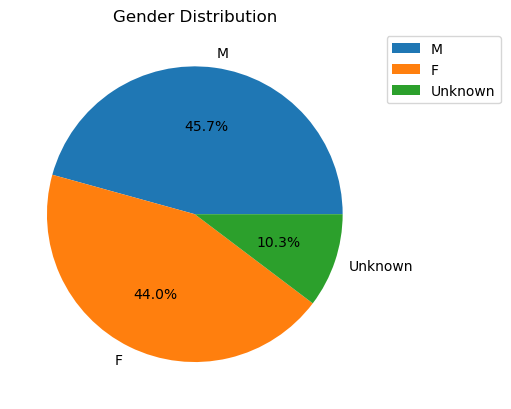

In [106]:
#Pie chart Gender Distribution

count = df['gender'].value_counts()
plt.pie(count.values, labels=count.index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

## Payment Method Distribution (Pie chart)

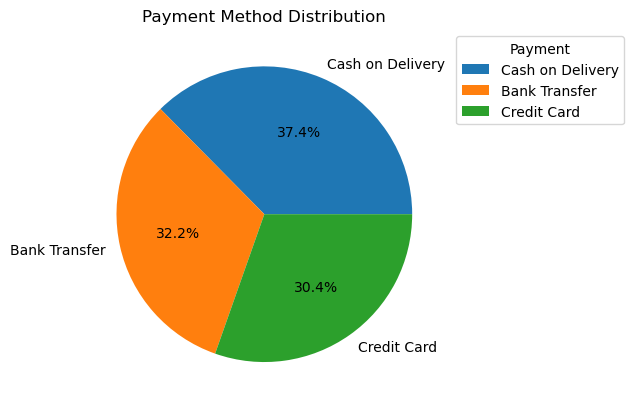

In [107]:
count=df['payment_method'].value_counts()
plt.pie(count.values, labels=count.index,autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.legend(title="Payment", loc='upper left', bbox_to_anchor=(1,1))
plt.show()

## Price Distribution (Histogram)

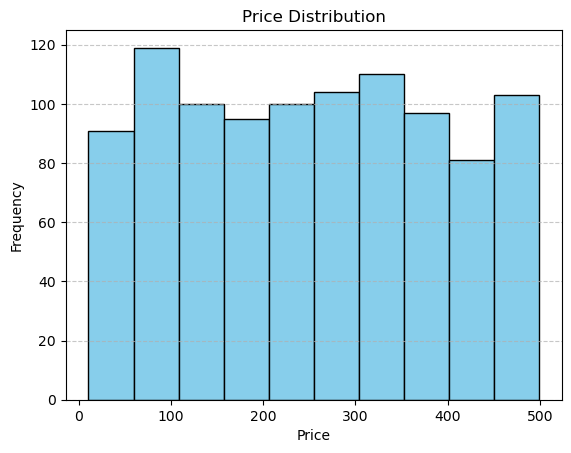

In [108]:
plt.hist(df['price'].dropna(), bins=10,color="skyblue",edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Customer Satisfaction (Histogram)

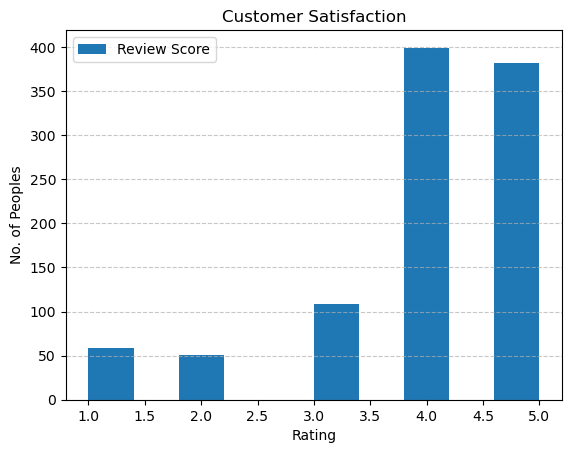

In [109]:
#histogram Customer Satisfaction
plt.hist(df['review_score'].dropna(), bins=10, label='Review Score')
plt.title("Customer Satisfaction")
plt.xlabel("Rating")
plt.ylabel("No. of Peoples")
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.legend()
plt.show()

## Quantity Distribution (Histogram)

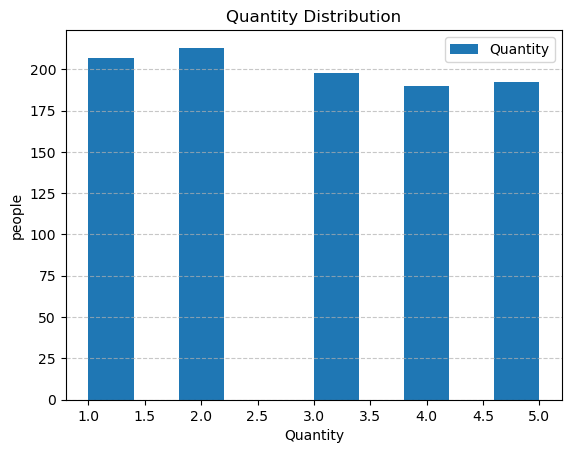

In [110]:
#histogram Quantity Distribution
plt.hist(df['quantity'].dropna(), bins=10, label='Quantity')
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("people")
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.legend()
plt.show()

## Price vs Quantity (Scatter plot)

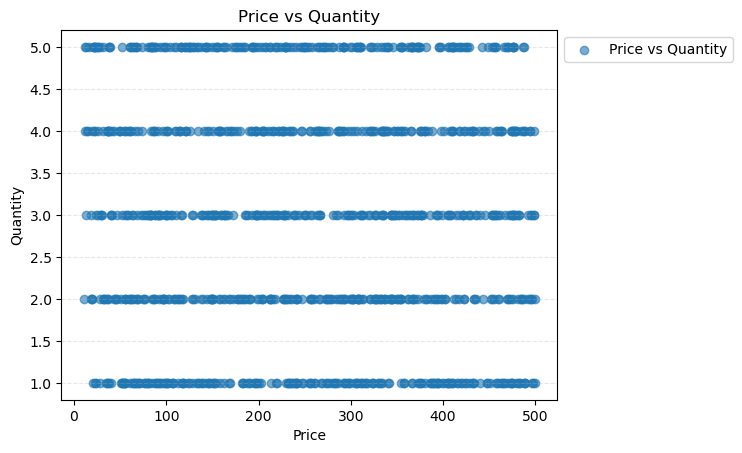

In [111]:
plt.scatter(df['price'], df['quantity'],alpha=0.6,label="Price vs Quantity")
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.grid(axis="y",linestyle="--",alpha=0.3)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

## Age vs Total Spending(Scatter plot)

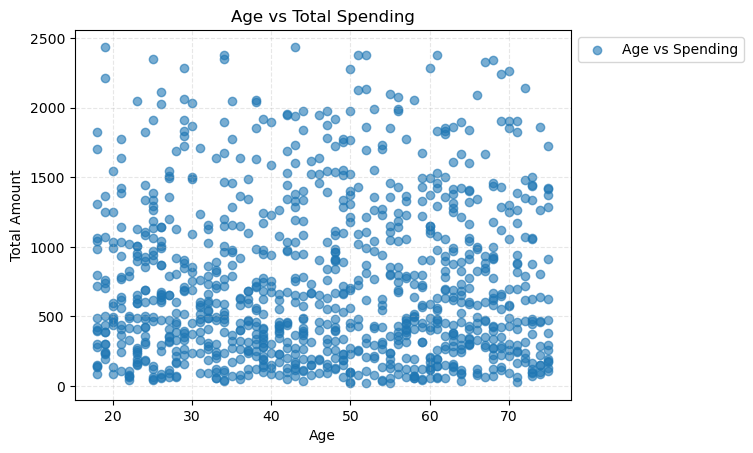

In [112]:
plt.scatter(df['age'], df['total_amount'], label='Age vs Spending',alpha=0.6)
plt.title("Age vs Total Spending")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.legend(bbox_to_anchor=(1,1))
plt.grid(linestyle="--",alpha=0.3)
plt.show()

## Price vs Review Score (Scatter Plot)


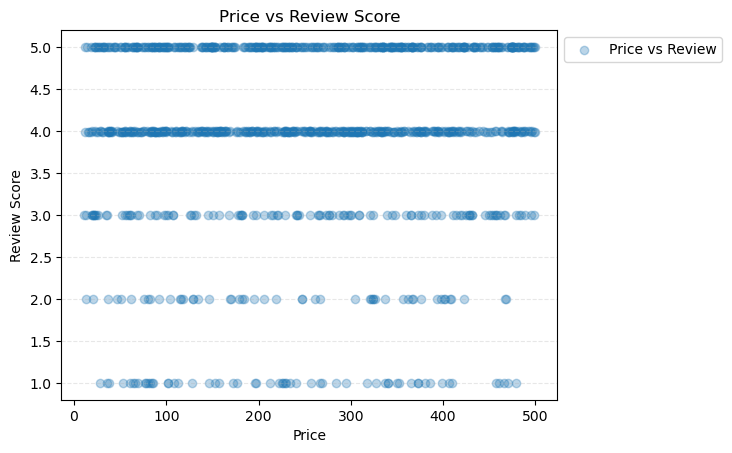

In [113]:
plt.scatter(df['price'], df['review_score'], label='Price vs Review',alpha=0.3)
plt.title("Price vs Review Score")
plt.xlabel("Price")
plt.ylabel("Review Score")
plt.grid(axis="y",linestyle="--",alpha=0.3)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

## Quantity vs Total Amount (Scatter Plot)

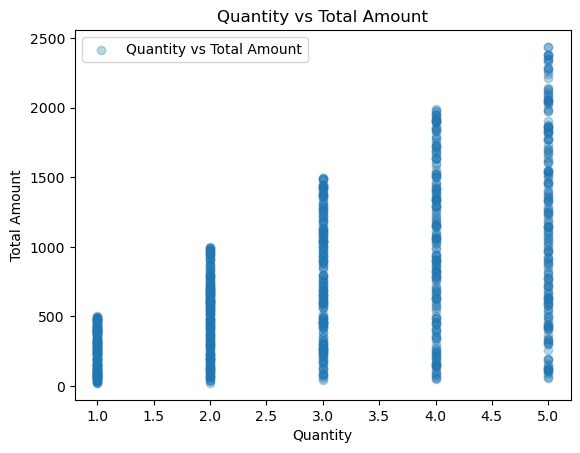

In [114]:
plt.scatter(df['quantity'], df['total_amount'], label='Quantity vs Total Amount',alpha=0.3)
plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.legend()
plt.show()

## Sales Over Time (Line Plot)

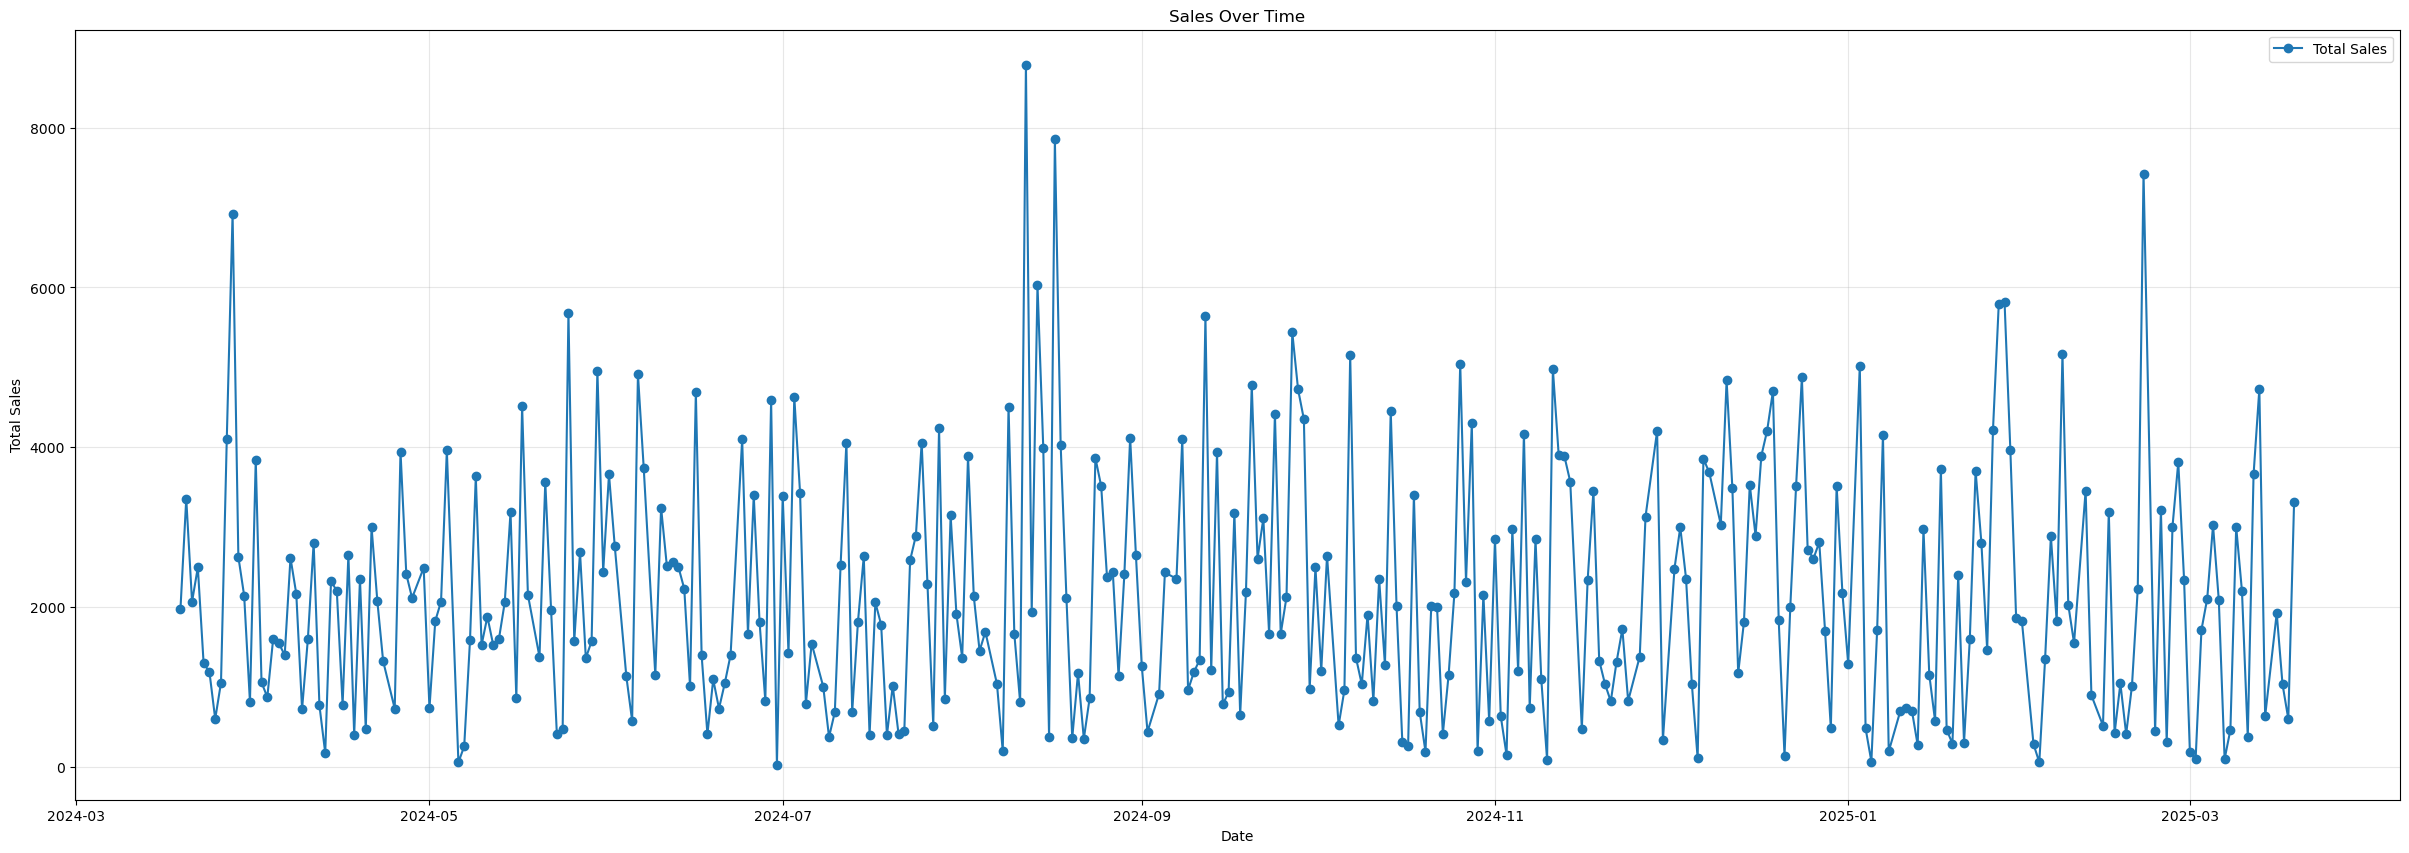

In [115]:
plt.figure(figsize=(30,10))
sales = df.groupby('order_date')['total_amount'].sum()   #It groups data by date and then adds all sales for each date
plt.plot(sales.index, sales.values, marker='o',label="Total Sales")
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Insights & Business Recommendations:

## 1. Category Analysis (Bar Plot)
- The bar plot shows that Sports & Outdoors has the highest count with 211 orders, followed by Electronics (207), Fashion (198), Books & Stationery (193), and Home & Living (191).
The difference between categories is relatively small, showing balanced demand across all categories.

**Business Insight:**
- The business should focus on Sports & Outdoors and Electronics by increasing inventory and promoting them to maximize sales, as they are the most demanded category by customer

## 2. Customer Demographics (Gender Distribution)
- The pie chart shows that Male customers (457, ~45.7%) are slightly more than Female customers (440, ~44%), while 103 customers (~10.3%) have unknown gender due to missing data orr some other reasons.

 **Business Insight:**
- Since gender distribution is nearly equal, the company should design balanced marketing strategies targeting both male and female customers rather than focusing on only one group.

## 3. Payment Method Analysis
- The pie chart shows that Cash on Delivery (374, ~37.4%) is the most commonly used payment method, followed by Bank Transfer (322, ~32.2%) and Credit Card (304, ~30.4%).

**Business Insight:**
- The business should ensure smooth Cash on Delivery operations since its the most used payment methods , while also offering incentives like cashback on Credit Card\UPI\digital wallet payments to shift customers toward digital payments.

## 4. Price Distribution (Histogram)
- The histogram shows that most products fall within the price rangeof ₹100 – ₹400 . The average price is ₹251.85, with the minimum being ₹10.72 and the maximum being ₹499.50.

**Business Insight:**
- The business should price most of its products between ₹100 and ₹400 to match customer preferences, as this is where the majority of purchases are are being done.

## 5. Quantity Distribution (Histogram)
- The histogram shows that customers generally purchase between 1 to 5 items, with an average of ~3 items per order. 50% of customers buy 3 or fewer items per transaction.

**Business Insight:**
- The business can introduce combo offers or bulk discounts for purchases of 4–5 items to push the average order quantity higher and increase revenue per transaction.

## 6. Customer Satisfaction (Review Score Histogram)
- The review score distribution shows an average rating of 3.99 out of 5, with 75% of customers giving a score of 5, indicating generally high satisfaction. However, some customers rated as low as 1, highlighting areas of concern.

**Business Insight:**
- The high average rating of ~4 indicates good product quality. However, the business should investigate customers who gave ratings of 1–2 and offer them follow-up support or discount coupons to improve retention.

## 7. Price vs Quantity (Scatter Plot)
- This plot shows no strong relationship between price and quantity purchased. Customers buy 1–5 items regardless of whether the price is low (₹10) or high (₹499), suggesting customers are not significantly price-sensitive on quantity.

**Business Insight:**
- Since price does not heavily affect quantity, the business can maintain current pricing without worrying that higher prices will reduce the number of items purchased per order.

## 8. Quantity vs Total Amount (Scatter Plot)
- This graph shows a clear positive relationship between quantity and total spending. Customers who buy 5 items spend significantly more, with total amounts reaching up to ₹2,437.65, compared to single-item buyers near ₹20.84.

**Business Insight:**
- Encouraging customers to buy more items will directly increase revenue. Strategies like "Buy 3 Get 1 Free" or free shipping above a quantity threshold can push customers to order more.

## 9. Age vs Total Spending (Scatter Plot)
- This plot shows that spending is spread across all age groups (18 to 75 years). However, the top spending age groups are age 30 (avg ₹1013.60), age 52 (avg ₹977.25), and age 29 (avg ₹947.18), making customers in their late 20s to early 30s and early 50s the highest spenders.
  
**Business Insight:**
- Targeted marketing campaigns should focus on customers aged 28–35 and 50–55, as they show the highest average spending and offer the most revenue potential.

## 10. Price vs Review Score (Scatter Plot)
- This plot shows no strong correlation between price and review score. Products priced as low as ₹10 and as high as ₹499 both receive ratings across the full range of 1 to 5, with the average sitting at 3.99.

**Business Insight:**
- It shows that higher price does not guarantee better reviews. The business should focus on product quality and delivery experience rather than assuming premium pricing will lead to higher customer satisfaction.


In [116]:
highest_sales=df.groupby('order_date')['total_amount'].sum().sort_values(ascending=False)
highest_sales


order_date
2024-08-12    8788.71
2024-08-17    7854.50
2025-02-21    7425.89
2024-03-28    6920.49
2024-08-14    6026.87
               ...   
2024-11-10      86.25
2025-01-05      63.44
2025-02-03      53.85
2024-05-06      52.50
2024-06-30      24.00
Name: total_amount, Length: 342, dtype: float64

## 11. Sales Over Time (Line Plot)
- The line plot shows fluctuating sales throughout the period, with the highest sales on 12th August 2024 (₹8,788.71), followed by 17th August 2024 (₹7,854.50) and 21st February 2025 (₹7,425.89). This indicates clear peak sales periods.

**Business Insight:**
- The business can plan inventory stocking and promotional campaigns around August, as it appears to be the strongest sales month. Low-sales periods should be targeted with discounts and offers to stabilize revenue throughout the year.



# Business Recommendations

1. **Inventory:** Increase stock for top-performing categories (e.g.,Sports and Outdoor and Electronics ).
2. **Pricing:** Keep most products in the ₹100–₹400 range as that's where 
   customer demand is highest.
3. **Payment:** Promote UPI/digital wallet offers since they will more convenient to both customer and the store.
4. **Marketing:** Target the most active age group with personalized campaigns.(32–61 years)
5. **Retention:** Customers with review scores below 3 should receive follow-up 
   emails/whatsapp/sms or discount coupons to improve satisfaction.

# Conclusion

This project analyzed the online retail dataset to uncover key patterns in 
customer behavior and sales trends.

Key takeaways:
- **Sports and Outdoor** is the most popular product category.
- Most customers fall in the **32–61 years** bracket and spend an average of **₹737.33** .
- Cash on delivery is the most preferred payment mode.
- Sales peak during **2024-07 to 2024-09**, suggesting seasonal demand.
- Review scores average around **3.99/5**, indicating **good** satisfaction.

The insights generated can directly guide inventory planning, pricing strategy, 
targeted marketing, and customer retention efforts.

In [117]:
df.to_csv('final_ds_dataset.csv',index=False)